### Checks

Merge `Urban Ward_Panel` and `Urban Ward_IFS` sheets. Add 2 columns, in_IFS and in_Panel.


1. All TV_CODES should show up at least once. Either one shape for a town or village (NaN Ward code) or multiple ward shapes with codes.
2. Which TV_Codes have we been given multiple shapes for (wards)? Should match or overdeliver on their promise.

Add column that says "Delivery State": 
- "FAIL - No shape(s) given", 
- "PASS - single Town/Village shape given (expected)", 
- "FAIL - only town shape given (but Ward shapes promised)", 
- "PASS - Ward shapes given", 
- "FAIL - Ward shapes given but sampled ward missing", 
- "PASS - subdistrict given only (expected)"

3. Also check population/summed up population matches the value in our reference.
4. Subdistrict codes for 3 states should show up for those states



#### OLD

- Sheet `Urban Ward_IFS` sheet: match the `TownVillage`-`UrbanWardVillage` columns (where it's not 0) to what's in the given dataset for each state - do these sampled wards exist in the shared shapes? Add column `Delivered by MapSolve`
    - If not, was it flagged as available? If yes flag as "Promised but not delivered ward shapes"
    - If yes, flag as delivered


`UrbanWardVillage`:
- If it's 0, it's a rural village, and there should just be NaN for Ward_C but one shape for the TV_Code (same as town)
- If it's non-zero, it's a sampled ward. If MapSolve has said available we should get wards. If they've said unavailable, the `Ward_C` should be null but the TV_Code should be there.


Only expect subdistrict boundaries for our sampled subdistricts - only check for subdistrict code existence:
- meghalaya
- tripura
- uttarakhand

## Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
# general
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm

# for plotting and coloring
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm

gpd.options.io_engine = "pyogrio"

In [3]:
from gridsample.utils import create_ids, create_gmap_links, save_shapefiles
from gridsample.mapping import create_interactive_map

In [4]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data"
CLEANED_DATA_DIR = (
    DATA_DIR / "02. Intermediate Outputs" / "00. Merge and Quality Checks" / "v7"
)
CLEANED_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
def generate_colormap(N):
    arr = np.arange(N) / N
    N_up = int(math.ceil(N / 7) * 7)
    arr.resize(N_up)
    arr = arr.reshape(7, N_up // 7).T.reshape(-1)
    ret = matplotlib.cm.hsv(arr)
    n = ret[:, 3].size
    a = n // 2
    b = n - a

    # Create arrays of exactly matching sizes
    for i in range(3):
        ret[0:a, i] *= np.linspace(0.2, 1, a)
    ret[a:, 3] *= np.linspace(1, 0.3, b)

    return ret[:N]  # Return only the requested number of colors

## 0. Load request excel

In [ ]:
excel_file = (
    RAW_DATA_DIR / "00. Boundary Requests" / "SamplingOutput_Summary_IFS & Panel.xlsx"
)

In [ ]:
ifs_df = pd.read_excel(excel_file, sheet_name="Urban Ward_IFS")
ifs_df["Selected in IFS Sample"] = "Yes"

In [ ]:
panel_df = pd.read_excel(excel_file, sheet_name="Urban Ward_Panel")
panel_df["Included in Panel Round 2"] = "No"
panel_df.loc[
    (panel_df["Included in Panel"] == "No")
    & (panel_df["Selected in IFS Sample"] == "No"),
    "Included in Panel Round 2",
] = "Yes"


In [ ]:
merged_df = panel_df.merge(
    ifs_df,
    on=list(ifs_df.columns.intersection(panel_df.columns)),
    how="outer",
    indicator="Source Sheet",
)
merged_df["Source Sheet"] = merged_df["Source Sheet"].replace(
    {
        "left_only": "Panel",
        "right_only": "IFS",
        "both": "Both Panel and IFS",
    }
)
merged_df

In [ ]:
# rename columns for clarity
merged_df = merged_df.rename(
    columns={
        "Selected in IFS Sample": "Sampled for IFS",
        "Included in Panel": "Sampled for Panel",
        "Included in Panel Round 2": "Sampled for Panel Round 2",
    },
)

In [ ]:
# check
print(
    "Left:",
    merged_df.loc[merged_df["Source Sheet"] == "IFS", "Sampled for IFS"].value_counts(),
)
print(
    "Right or Both",
    merged_df.loc[merged_df["Source Sheet"] != "IFS", "Sampled for IFS"].value_counts(),
)

In [ ]:
# fill NaN values in "Included in Panel" column to No
merged_df["Sampled for Panel"].fillna("No", inplace=True)
merged_df["Sampled for Panel Round 2"].fillna("No", inplace=True)

# sort and reset index
merged_df = merged_df.sort_values(
    by=["State", "District", "Subdistrict", "TownVillage", "UrbanWardVillage"]
).reset_index(drop=True)

In [ ]:
merged_df

In [ ]:
merged_df.to_csv(CLEANED_DATA_DIR / "Merged Panel and IFS Wards.csv", index=False)

In [ ]:
# get unique across district and subdistrict both
len(merged_df[["State", "District", "Subdistrict"]].drop_duplicates())

In [ ]:
subdistrict_only_state_names = ["MEGHALAYA", "TRIPURA", "UTTARAKHAND"]
merged_df.loc[
    merged_df["State_Name"].isin(subdistrict_only_state_names), ["State", "State_Name"]
].value_counts()

In [ ]:
subdistrict_only_state_codes = [17, 16, 5]

In [ ]:
merged_df.columns

#### Check for duplicated wards in our own sample

In [ ]:
duplicated_sampled_wards = merged_df[
    merged_df[["TownVillage", "UrbanWardVillage"]].duplicated(keep=False)
].sort_values(["TownVillage", "UrbanWardVillage"])
duplicated_sampled_wards

In [ ]:
duplicated_sampled_wards.to_csv(
    CLEANED_DATA_DIR / "Duplicated Sampled Wards.csv", index=False
)

## 1. Load all boundaries

In [17]:
# get all filepaths that end in `gpkg` inside the RAW_DATA_DIR / 0.1. MapSolve Boundaries
boundaries_dir = RAW_DATA_DIR / "01. MapSolve Boundaries"
gpkg_files_all = list(boundaries_dir.glob("**/*.gpkg"))
gpkg_files_all = [f for f in gpkg_files_all if f.is_file()]

In [18]:
# # drop any with the word "Sub-District" in the filename
# gpkg_files_VTW = [f for f in gpkg_files_all if "Sub-District" not in f.name]

In [19]:
# load all shapes into one gdf
gdf_list = []
for filepath in gpkg_files_all:
    gdf_list.append(gpd.read_file(filepath))
gdf = pd.concat(gdf_list, ignore_index=True)

In [20]:
gdf = gdf.drop_duplicates()

## 2. Checks

### Any MapSolve rows with missing TV code?

In [ ]:
gdf_no_TV_code_filtered = gdf[gdf["TV_C"].isna()]
gdf_no_TV_code_filtered

In [ ]:
gdf_no_TV_code_filtered.to_csv(
    CLEANED_DATA_DIR / "MapSolve Data without TV Codes.csv", index=False
)

### Request satisfaction check

In [ ]:
given_states_list = list(gdf["State_C"].unique())
given_states_list.append(
    90
)  # manually add 90 for Telangana / Andhra Pradesh discrepency
len(given_states_list)

In [ ]:
merged_df.loc[merged_df["State"].isin(given_states_list), "State_Name"].unique()

In [ ]:
merged_df["State Shared by MapSolve"] = False
merged_df.loc[
    merged_df["State"].isin(given_states_list), "State Shared by MapSolve"
] = True

In [ ]:
len(merged_df[~merged_df["State Shared by MapSolve"]])

In [ ]:
merged_df["State Changed"] = "No"
merged_df.loc[merged_df["State_Name"] == "TELANGANA", "State Changed"] = (
    "Previously Andhra Pradesh"
)

In [ ]:
merged_df

#### Check for wards

In [ ]:
merged_df["PCA_ID"] = (
    merged_df["TownVillage"].astype(str)
    + "-"
    + merged_df["UrbanWardVillage"].astype(str)
)
given_ward_ids = gdf["PCA_ID"].unique()

merged_df["Ward Boundary Given"] = False
merged_df.loc[merged_df["PCA_ID"].isin(given_ward_ids), "Ward Boundary Given"] = True

In [ ]:
len(set(merged_df["PCA_ID"]).intersection(given_ward_ids))

#### Check for TownVillage codes

In [ ]:
given_TV_ids = set(
    gdf.loc[
        gdf["Ward_C"].isna() & gdf["TV_C"].notna(),
        "TV_C",
    ].astype(int)
)

merged_df["TV Boundary Given"] = False
merged_df.loc[
    merged_df["TownVillage"].astype(int).isin(given_TV_ids),
    "TV Boundary Given",
] = True

#### Check for SubDistricts

In [ ]:
given_subdist_ids = set(
    gdf.loc[
        gdf["Ward_C"].isna() & gdf["TV_C"].isna() & gdf["SubDist_C"].notna(),
        "SubDist_C",
    ].astype(int)
)

merged_df["SubDistrict Boundary Given"] = False
merged_df.loc[
    merged_df["Subdistrict"].astype(int).isin(given_subdist_ids),
    "SubDistrict Boundary Given",
] = True

#### Fill in Delivery State

In [ ]:
# - "FAIL - No shape(s) given",
# - "PASS - Ward shapes given",
# - "FAIL - only town shape given (but Ward shapes promised)",
# - "PASS - single Town/Village shape given (expected)",
# - "PASS - subdistrict given only (expected)"

# not implemented:
# - "FAIL - Ward shapes given but sampled ward missing",

In [ ]:
## baseline
merged_df["Delivery State"] = "BAD - No boundary(s) given"

## subdistrict
merged_df.loc[
    (merged_df["Ward Boundary Available with MapSolve"] == "No")
    & merged_df["SubDistrict Boundary Given"],
    "Delivery State",
] = "GOOD - Subdistrict boundary given as expected"
merged_df.loc[
    (merged_df["Ward Boundary Available with MapSolve"] == "Yes")
    & merged_df["SubDistrict Boundary Given"],
    "Delivery State",
] = "BAD - Subdistrict boundary given but Ward boundaries expected"

# tripura > dukli special case
merged_df.loc[
    (merged_df["State_Name"] == "TRIPURA") & (merged_df["Subd_Name"] == "Dukli"),
    "Delivery State",
] = "GOOD - Subdistrict boundary given as expected"

## town/village
merged_df.loc[
    (merged_df["Ward Boundary Available with MapSolve"] == "No")
    & merged_df["TV Boundary Given"],
    "Delivery State",
] = "GOOD - Town/Village boundary given as expected"
merged_df.loc[
    (merged_df["Ward Boundary Available with MapSolve"] == "Yes")
    & merged_df["TV Boundary Given"],
    "Delivery State",
] = "BAD - Town/Village boundary given but Ward boundaries expected"

## ward
merged_df.loc[
    (merged_df["Ward Boundary Available with MapSolve"] == "No")
    & merged_df["Ward Boundary Given"],
    "Delivery State",
] = "BETTER - Ward boundary given but only TV or Subdistrict was expected"
merged_df.loc[
    (merged_df["Ward Boundary Available with MapSolve"] == "Yes")
    & merged_df["Ward Boundary Given"],
    "Delivery State",
] = "GOOD - Ward boundary given as expected"

In [ ]:
merged_df["Delivery State"].value_counts()

#### Add `PSU Type` column

In [ ]:
merged_df["Delivery State"].unique()

In [13]:
psu_mapping = {
    "BETTER - Ward boundary given but only TV or Subdistrict was expected": "ward",
    "GOOD - Town/Village boundary given as expected": "town_village",
    "GOOD - Ward boundary given as expected": "ward",
    "GOOD - Subdistrict boundary given as expected": "subdistrict",
    "BAD - Town/Village boundary given but Ward boundaries expected": "town_village",
    "BAD - No boundary(s) given": "none",
    "BAD - Subdistrict boundary given but Ward boundaries expected": "subdistrict",
}
# create a new column in merged_df called PSU Type
merged_df["PSU Type"] = merged_df["Delivery State"].map(psu_mapping)

NameError: name 'merged_df' is not defined

#### Add `Ward Count` columns for both, IFS only, and Panel only

In [ ]:
merged_df["Ward Count (All)"] = 0

merged_df.loc[merged_df["PSU Type"] == "ward", "Ward Count (All)"] = 1
merged_df.loc[merged_df["PSU Type"] == "town_village", "Ward Count (All)"] = (
    merged_df[merged_df["PSU Type"] == "town_village"]
    .groupby("TownVillage")["UrbanWardVillage"]
    .transform("nunique")
)
merged_df.loc[merged_df["PSU Type"] == "subdistrict", "Ward Count (All)"] = (
    merged_df[merged_df["PSU Type"] == "subdistrict"]
    .groupby("Subdistrict")["UrbanWardVillage"]
    .transform("nunique")
)
merged_df["Ward Count (All)"] = merged_df["Ward Count (All)"].astype(int)

In [ ]:
merged_df["Ward Count IFS"] = 0

merged_df.loc[
    (merged_df["Sampled for IFS"] == "Yes") & (merged_df["PSU Type"] == "ward"),
    "Ward Count IFS",
] = 1
merged_df.loc[
    (merged_df["Sampled for IFS"] == "Yes") & (merged_df["PSU Type"] == "town_village"),
    "Ward Count IFS",
] = (
    merged_df[
        (merged_df["Sampled for IFS"] == "Yes")
        & (merged_df["PSU Type"] == "town_village")
    ]
    .groupby("TownVillage")["UrbanWardVillage"]
    .transform("nunique")
)
merged_df.loc[
    (merged_df["Sampled for IFS"] == "Yes") & (merged_df["PSU Type"] == "subdistrict"),
    "Ward Count IFS",
] = (
    merged_df[
        (merged_df["Sampled for IFS"] == "Yes")
        & (merged_df["PSU Type"] == "subdistrict")
    ]
    .groupby("Subdistrict")["UrbanWardVillage"]
    .transform("nunique")
)
merged_df["Ward Count IFS"] = merged_df["Ward Count IFS"].astype(int)

In [ ]:
merged_df["Ward Count Panel"] = 0

merged_df.loc[
    (merged_df["Sampled for Panel"] == "Yes") & (merged_df["PSU Type"] == "ward"),
    "Ward Count Panel",
] = 1
merged_df.loc[
    (merged_df["Sampled for Panel"] == "Yes")
    & (merged_df["PSU Type"] == "town_village"),
    "Ward Count Panel",
] = (
    merged_df[
        (merged_df["Sampled for Panel"] == "Yes")
        & (merged_df["PSU Type"] == "town_village")
    ]
    .groupby("TownVillage")["UrbanWardVillage"]
    .transform("nunique")
)
merged_df.loc[
    (merged_df["Sampled for Panel"] == "Yes")
    & (merged_df["PSU Type"] == "subdistrict"),
    "Ward Count Panel",
] = (
    merged_df[
        (merged_df["Sampled for Panel"] == "Yes")
        & (merged_df["PSU Type"] == "subdistrict")
    ]
    .groupby("Subdistrict")["UrbanWardVillage"]
    .transform("nunique")
)
merged_df["Ward Count Panel"] = merged_df["Ward Count Panel"].astype(int)

In [ ]:
merged_df["Ward Count Panel Round 2"] = 0

merged_df.loc[
    (merged_df["Sampled for Panel Round 2"] == "Yes")
    & (merged_df["PSU Type"] == "ward"),
    "Ward Count Panel Round 2",
] = 1
merged_df.loc[
    (merged_df["Sampled for Panel Round 2"] == "Yes")
    & (merged_df["PSU Type"] == "town_village"),
    "Ward Count Panel Round 2",
] = (
    merged_df[
        (merged_df["Sampled for Panel Round 2"] == "Yes")
        & (merged_df["PSU Type"] == "town_village")
    ]
    .groupby("TownVillage")["UrbanWardVillage"]
    .transform("nunique")
)
merged_df.loc[
    (merged_df["Sampled for Panel Round 2"] == "Yes")
    & (merged_df["PSU Type"] == "subdistrict"),
    "Ward Count Panel Round 2",
] = (
    merged_df[
        (merged_df["Sampled for Panel Round 2"] == "Yes")
        & (merged_df["PSU Type"] == "subdistrict")
    ]
    .groupby("Subdistrict")["UrbanWardVillage"]
    .transform("nunique")
)
merged_df["Ward Count Panel Round 2"] = merged_df["Ward Count Panel Round 2"].astype(
    int
)

In [ ]:
merged_df

In [ ]:
merged_df[
    (
        merged_df["Ward Count IFS"]
        + merged_df["Ward Count Panel"]
        + merged_df["Ward Count Panel Round 2"]
    )
    != merged_df["Ward Count (All)"]
]

#### Reorder columns

In [ ]:
reordered_columns = [
    "State",
    "State_Name",
    "District",
    "District_Name",
    "Subdistrict",
    "Subd_Name",
    "TownVillage",
    "UrbanWardVillage",
    "WardVillage_Name",
    "PCA_ID",
    "TRU",
    "WardVillage_Pop",
    "Subd_Pop",
    "State_Pop",
    "WardVillageID",
    "Ward Boundary Available with MapSolve",
    "Source Sheet",
    "Sampled for Panel",
    "Sampled for Panel Round 2",
    "Sampled for IFS",
    "State Shared by MapSolve",
    "State Changed",
    "Ward Boundary Given",
    "TV Boundary Given",
    "SubDistrict Boundary Given",
    "Delivery State",
    "PSU Type",
    "Ward Count IFS",
    "Ward Count Panel",
    "Ward Count Panel Round 2",
    "Ward Count (All)",
]
merged_df = merged_df[reordered_columns]

#### Save

In [ ]:
merged_df.to_csv(CLEANED_DATA_DIR / "Merged Wards with Quality Checks.csv", index=False)

In [ ]:
if not merged_df["State Shared by MapSolve"].all():
    print("There are states in the merged data that are not shared by MapSolve:")
    print(merged_df[~merged_df["State Shared by MapSolve"]]["State"].unique())
    print("Saving the states for which we DO have data separately:")
    merged_df[merged_df["State Shared by MapSolve"]].to_csv(
        CLEANED_DATA_DIR / "Merged Wards with Quality Checks - Shared States.csv",
        index=False,
    )

#### Save per-state stats

In [ ]:
# Get counts of delivery states by state
delivery_state_counts = (
    merged_df[merged_df["State"].isin(given_states_list)]
    .groupby("State")["Delivery State"]
    .value_counts()
)

# Convert to a more readable DataFrame format
delivery_state_pivot = delivery_state_counts.unstack(fill_value=0).reset_index()

# Sort by state code
delivery_state_pivot = delivery_state_pivot.sort_values(by="State")

# Add state names for better readability
state_name_mapping = (
    merged_df[["State", "State_Name"]]
    .drop_duplicates()
    .set_index("State")["State_Name"]
)
delivery_state_pivot["State_Name"] = delivery_state_pivot["State"].map(
    state_name_mapping
)

# Reorder columns to show State_Name first
columns = ["State", "State_Name"] + [
    col for col in delivery_state_pivot.columns if col not in ["State", "State_Name"]
]
delivery_state_pivot = delivery_state_pivot[columns]

# transform the DataFrame to have the delivery states as rows and state names as columns
delivery_state_pivot.drop(columns=["State"], inplace=True)
delivery_state_pivot = delivery_state_pivot.set_index("State_Name").T.reset_index()
delivery_state_pivot

In [ ]:
# add a total column as the second column
delivery_state_pivot.insert(1, "Total", delivery_state_pivot.iloc[:, 1:].sum(axis=1))

In [ ]:
delivery_state_pivot

In [ ]:
delivery_state_pivot.to_csv(
    CLEANED_DATA_DIR / "Delivery State Counts By State.csv", index=False
)

#### Old

In [ ]:
unique_requested_tv_codes = set(
    merged_df[merged_df["State Shared by MapSolve"]]["TownVillage"]
)
unique_received_tv_codes = set(gdf.loc[~gdf["TV_C"].isna(), "TV_C"].astype(int))
matched_tv_codes = unique_received_tv_codes.intersection(unique_requested_tv_codes)

In [ ]:
print("Number of requested TV codes:", len(unique_requested_tv_codes))
print("Number of received TV codes:", len(unique_received_tv_codes))

print("Number of matched TV codes:", len(matched_tv_codes))
print(
    "Number of TV codes not received:",
    len(unique_requested_tv_codes.difference(matched_tv_codes)),
)

In [ ]:
# show the received breakdown by state
received_pivot_table = (
    merged_df[merged_df["State Shared by MapSolve"]]
    .groupby(
        [
            "State",
            "State_Name",
            "District",
            "District_Name",
            "Subdistrict",
            "Subd_Name",
        ]
    )["Delivery State"]
    .value_counts()
    .unstack(fill_value=0)
).reset_index()

# received_pivot_table.rename(
#     columns={True: "TV_Codes Received", False: "TV_Codes Not Received"}, inplace=True
# )

In [ ]:
received_pivot_table

In [ ]:
pivot_table_not_received = received_pivot_table[
    received_pivot_table["BAD - No boundary(s) given"] > 0
]
pivot_table_not_received


In [ ]:
pivot_table_not_received.to_csv(
    CLEANED_DATA_DIR / "Requested TV Codes Not Received Subdistrict Breakdown.csv",
    index=False,
)

In [ ]:
requested_tv_codes_not_received = merged_df[
    (merged_df["State Shared by MapSolve"])
    & (merged_df["Delivery State"] == "BAD - No boundary(s) given")
]
requested_tv_codes_not_received

In [ ]:
requested_tv_codes_not_received.to_csv(
    CLEANED_DATA_DIR / "Requested TV Codes Not Received.csv", index=False
)

## Post-sampling checks

In [6]:
OUTPUT_DATA_DIR = DATA_DIR / "03. Final Outputs"

In [7]:
v4 = gpd.read_parquet(
    OUTPUT_DATA_DIR
    / "v4"
    / "01. Sampled Rooftop Data"
    / "sampled_rooftops_snapped_points.parquet"
)
v4["source_version"] = "v4"

# v5_filtered = gpd.read_parquet(
#     OUTPUT_DATA_DIR
#     / "v5_filtered"
#     / "01. Sampled Rooftop Data"
#     / "sampled_rooftops_snapped_points.parquet"
# )
# v5_filtered["source_version"] = "v5_filtered"

v6_uttarakhand = gpd.read_parquet(
    OUTPUT_DATA_DIR
    / "v6_uttarakhand"
    / "01. Sampled Rooftop Data"
    / "Uttarakhand"
    / "Uttarakhand_sampled_rooftops_snapped_points.parquet"
)
v6_uttarakhand["source_version"] = "v6_uttarakhand"

In [8]:
combined_rooftops_gdf = gpd.GeoDataFrame(
    pd.concat([v4, v6_uttarakhand], ignore_index=True)
)

In [9]:
combined_rooftops_gdf.columns

Index(['Rooftop State ID', 'Rooftop PSU ID', 'Rooftop Unique ID',
       'Geometry Type', 'geometry', 'latitude', 'longitude', 'gmap_link',
       'latitude_original', 'longitude_original', 'gmap_link_original',
       'PSU ID', 'PSU Type', 'Ward Count', 'Ward Count (Both)', 'State Code',
       'State Name', 'State Changed', 'District Code', 'District Name',
       'Subdistrict Code', 'Subdistrict Name', 'TV Code', 'TV Name_MapSolve',
       'Ward Code', 'Ward/Village Name', 'Urban/Rural', 'PCA_ID',
       'Ward Population', 'Subdistrict Population', 'State Population',
       'Ward Boundary Available with MapSolve', 'Ward Boundary Given',
       'TV Boundary Given', 'SubDistrict Boundary Given', 'Delivery State',
       'State Code_MapSolve', 'State Name_MapSolve', 'District Code_MapSolve',
       'District Name_MapSolve', 'Subdistrict Code_MapSolve',
       'Subdistrict Name_MapSolve', 'TV Code_MapSolve', 'Ward Code_MapSolve',
       'PCA_ID_MapSolve', 'PSU Total Population_MapSolve

In [10]:
duplicated_gdf = combined_rooftops_gdf[
    combined_rooftops_gdf["Rooftop Unique ID"].duplicated(keep=False)
].sort_values("Rooftop Unique ID")

In [11]:
# load Red's DQ checks
missing_ward_df = pd.read_excel(
    CLEANED_DATA_DIR.parent.parent / "red_sample_dq_check_v3.xlsx",
    sheet_name="ward_unmerged",
)
missing_tv_df = pd.read_excel(
    CLEANED_DATA_DIR.parent.parent / "red_sample_dq_check_v3.xlsx",
    sheet_name="tv_unmerged",
)
missing_subd_df = pd.read_excel(
    CLEANED_DATA_DIR.parent.parent / "red_sample_dq_check_v3.xlsx",
    sheet_name="subdistrict_unmerged",
)

In [14]:
missing_ward_df["psutype"] = missing_ward_df["deliverystate"].map(psu_mapping)
missing_tv_df["psutype"] = missing_tv_df["deliverystate"].map(psu_mapping)
missing_subd_df["psutype"] = missing_subd_df["deliverystate"].map(psu_mapping)

### Ward

In [15]:
missing_ward_df.groupby("deliverystate").size()

deliverystate
GOOD - Subdistrict boundary given as expected     5
GOOD - Town/Village boundary given as expected    5
GOOD - Ward boundary given as expected            1
dtype: int64

In [21]:
# add a new column that says "PSU Type in Rooftop Sample" that is true if found, False if not
missing_ward_df["PSU Type in Rooftop Sample"] = False

missing_ward_df.loc[
    missing_ward_df["psutype"] == "ward",
    "PSU Type in Rooftop Sample",
] = missing_ward_df["pca_id"].isin(combined_rooftops_gdf["PCA_ID"].unique())

missing_ward_df.loc[
    missing_ward_df["psutype"] == "town_village",
    "PSU Type in Rooftop Sample",
] = missing_ward_df["townvillage"].isin(
    combined_rooftops_gdf[
        combined_rooftops_gdf["Ward Code"].isnull()
        & combined_rooftops_gdf["TV Code"].notna()
    ]["TV Code"].unique()
)

missing_ward_df.loc[
    missing_ward_df["psutype"] == "subdistrict",
    "PSU Type in Rooftop Sample",
] = missing_ward_df["subdistrict"].isin(
    combined_rooftops_gdf[
        (combined_rooftops_gdf["Ward Code"].isnull())
        & (combined_rooftops_gdf["TV Code"].isnull())
        & (combined_rooftops_gdf["Subdistrict Code"].notna())
    ]["Subdistrict Code"].unique()
)

# add a new column that says "PSU Type in MapSolve Shapes" that is based on the "gdf" dataset that is true if found, False if not
missing_ward_df["PSU Type in MapSolve Shapes"] = False

missing_ward_df.loc[
    missing_ward_df["psutype"] == "ward",
    "PSU Type in MapSolve Shapes",
] = missing_ward_df["pca_id"].isin(gdf["PCA_ID"].unique())

missing_ward_df.loc[
    missing_ward_df["psutype"] == "town_village",
    "PSU Type in MapSolve Shapes",
] = missing_ward_df["townvillage"].isin(
    gdf[gdf["Ward_C"].isnull() & gdf["TV_C"].notna()]["TV_C"].unique()
)

missing_ward_df.loc[
    missing_ward_df["psutype"] == "subdistrict",
    "PSU Type in MapSolve Shapes",
] = missing_ward_df["subdistrict"].isin(
    gdf[(gdf["Ward_C"].isnull()) & (gdf["TV_C"].isnull()) & (gdf["SubDist_C"].notna())][
        "SubDist_C"
    ].unique()
)

In [22]:
missing_ward_df

,state,state_name,district,district_name,subdistrict,subd_name,townvillage,ward_id,wardvillage_name,pca_id,...,TRU,WardVillage_Pop,Subd_Pop,State_Pop,WardVillageID,WardBoundaryAvailablewithMap,_m2,_merge,PSU Type in Rooftop Sample,PSU Type in MapSolve Shapes
0,6,HARYANA,86,Gurgaon,417,Gurgaon,800429,20,Gurgaon (M Corp.) WARD NO.-0020,800429-20,...,Urban,28088,"9,77,337","2,53,51,462",086-00417-800429-0020,No,Using only (2),Matched (3),False,True
1,32,KERALA,601,Thiruvananthapuram,5691,Thiruvananthapuram,803312,20,Thiruvananthapuram (M Corp.) WARD NO.-0020,803312-20,...,Urban,28088,"9,77,337","2,53,51,462",086-00417-800429-0020,No,Using only (2),Matched (3),False,True
2,9,UTTAR PRADESH,150,Bareilly,787,Bareilly,800866,48,Bareilly (M Corp.) WARD NO.-0048,800866-48,...,Urban,16965,"16,28,338","19,98,12,341",150-00787-800866-0048,No,Using only (2),Matched (3),False,True
3,27,MAHARASHTRA,515,Aurangabad,4137,Aurangabad,802765,96,Aurangabad (M Corp.) WARD NO.-0096,802765-96,...,Urban,8822,"15,90,374","11,23,74,333",515-04137-802765-0096,No,Using only (2),Matched (3),False,True
4,7,NCT OF DELHI,97,South West,451,Najafgarh,64052,137,Roshan Pura alias Dichaon Khurd (CT) WARD NO.-...,64052-137,...,Urban,57217,"13,65,152","1,67,87,941",097-00451-064052-0137,No,Using only (2),Matched (3),False,True
5,20,JHARKHAND,357,Purbi Singhbhum,2606,Golmuri-Cum-Jugsalai,801781,138,Jamshedpur (NAC) WARD NO.-0138,801781-138,...,Urban,7973,"12,60,201","3,29,88,134",357-02606-801781-0138,No,Using only (2),Matched (3),False,True
6,7,NCT OF DELHI,98,South,454,Hauz Khas,64066,175,Jona Pur (CT) WARD NO.-0175,64066-175,...,Urban,10635,"12,31,293","1,67,87,941",098-00454-064066-0175,No,Using only (2),Matched (3),False,True
7,20,JHARKHAND,357,Purbi Singhbhum,2606,Golmuri-Cum-Jugsalai,801781,214,Jamshedpur (NAC) WARD NO.-0214,801781-214,...,Urban,4284,"12,60,201","3,29,88,134",357-02606-801781-0214,No,Using only (2),Matched (3),False,True
8,7,NCT OF DELHI,92,North East,436,Seelam Pur,63979,258,Gokal Pur (CT) WARD NO.-0258,63979-258,...,Urban,36580,"13,78,779","1,67,87,941",092-00436-063979-0258,No,Using only (2),Matched (3),False,True
9,7,NCT OF DELHI,92,North East,436,Seelam Pur,63972,261,Jiwan Pur alias Johri Pur (CT) WARD NO.-0261,63972-261,...,Urban,43054,"13,78,779","1,67,87,941",092-00436-063972-0261,No,Using only (2),Matched (3),False,True


In [23]:
missing_ward_df["PSU Type in Rooftop Sample"].value_counts()

PSU Type in Rooftop Sample
False    11
Name: count, dtype: int64

### TV

In [24]:
missing_tv_df.groupby("deliverystate").size()

deliverystate
BAD - No boundary(s) given                                        2
BAD - Subdistrict boundary given but Ward boundaries expected     1
GOOD - Subdistrict boundary given as expected                    15
GOOD - Town/Village boundary given as expected                   27
GOOD - Ward boundary given as expected                            3
dtype: int64

In [25]:
# add a new column that says "PSU Type in Rooftop Sample" that is true if found, False if not
missing_tv_df["PSU Type in Rooftop Sample"] = False

missing_tv_df.loc[
    missing_tv_df["psutype"].isin(["ward"]),
    "PSU Type in Rooftop Sample",
] = missing_tv_df["pca_id"].isin(combined_rooftops_gdf["PCA_ID"].unique())

missing_tv_df.loc[
    missing_tv_df["psutype"] == "town_village",
    "PSU Type in Rooftop Sample",
] = missing_tv_df["tv_id"].isin(
    combined_rooftops_gdf[
        combined_rooftops_gdf["Ward Code"].isnull()
        & combined_rooftops_gdf["TV Code"].notna()
    ]["TV Code"].unique()
)

missing_tv_df.loc[
    missing_tv_df["psutype"] == "subdistrict",
    "PSU Type in Rooftop Sample",
] = missing_tv_df["subdistrict"].isin(
    combined_rooftops_gdf[
        (combined_rooftops_gdf["Ward Code"].isnull())
        & (combined_rooftops_gdf["TV Code"].isnull())
        & (combined_rooftops_gdf["Subdistrict Code"].notna())
    ]["Subdistrict Code"].unique()
)

# add a new column that says "PSU Type in MapSolve Shapes" that is based on the "gdf" dataset that is true if found, False if not
missing_tv_df["PSU Type in MapSolve Shapes"] = False

missing_tv_df.loc[
    missing_tv_df["psutype"].isin(["ward"]),
    "PSU Type in MapSolve Shapes",
] = missing_tv_df["pca_id"].isin(gdf["PCA_ID"].unique())

missing_tv_df.loc[
    missing_tv_df["psutype"] == "town_village",
    "PSU Type in MapSolve Shapes",
] = missing_tv_df["tv_id"].isin(
    gdf[gdf["Ward_C"].isnull() & gdf["TV_C"].notna()]["TV_C"].unique()
)

missing_tv_df.loc[
    missing_tv_df["psutype"] == "subdistrict",
    "PSU Type in MapSolve Shapes",
] = missing_tv_df["subdistrict"].isin(
    gdf[(gdf["Ward_C"].isnull()) & (gdf["TV_C"].isnull()) & (gdf["SubDist_C"].notna())][
        "SubDist_C"
    ].unique()
)

In [26]:
missing_tv_df

,state,state_name,district,district_name,subdistrict,subd_name,tv_id,urbanwardvillage,wardvillage_name,pca_id,...,Subd_Pop,State_Pop,WardVillageID,WardBoundaryAvailablewithMap,tv_ward_count,tv_sample_count,_m2,_merge,PSU Type in Rooftop Sample,PSU Type in MapSolve Shapes
0,7,NCT OF DELHI,90,North West,430,Narela,63922,28,Bawana (CT) WARD NO.-0028,63922-28,...,"8,09,913","1,67,87,941",090-00430-063922-0028,No,1,25,Using only (2),Matched (3),False,True
1,7,NCT OF DELHI,90,North West,431,Saraswati Vihar,63948,37,Sultan Pur Majra (CT) WARD NO.-0037,63948-37,...,"22,50,816","1,67,87,941",090-00431-063948-0040,No,2,50,Using only (2),Matched (3),False,True
2,7,NCT OF DELHI,90,North West,431,Saraswati Vihar,63948,40,Sultan Pur Majra (CT) WARD NO.-0040,63948-40,...,"22,50,816","1,67,87,941",090-00431-063948-0040,No,2,50,Using only (2),Matched (3),False,True
3,7,NCT OF DELHI,92,North East,436,Seelam Pur,63971,270,Dayal Pur (CT) WARD NO.-0270,63971-270,...,"13,78,779","1,67,87,941",092-00436-063971-0270,No,1,25,Using only (2),Matched (3),False,True
4,7,NCT OF DELHI,92,North East,436,Seelam Pur,63972,261,Jiwan Pur alias Johri Pur (CT) WARD NO.-0261,63972-261,...,"13,78,779","1,67,87,941",092-00436-063972-0261,No,1,25,Using only (2),Matched (3),False,True
5,7,NCT OF DELHI,92,North East,436,Seelam Pur,63979,258,Gokal Pur (CT) WARD NO.-0258,63979-258,...,"13,78,779","1,67,87,941",092-00436-063979-0258,No,1,25,Using only (2),Matched (3),False,True
6,7,NCT OF DELHI,96,West,450,Punjabi Bagh,63999,44,Nangloi Jat (CT) WARD NO.-0044,63999-44,...,"7,99,453","1,67,87,941",096-00450-063999-0044,No,1,25,Using only (2),Matched (3),False,True
7,7,NCT OF DELHI,96,West,450,Punjabi Bagh,64001,31,Mundka (CT) WARD NO.-0031,64001-31,...,"7,99,453","1,67,87,941",096-00450-064001-0031,No,1,25,Using only (2),Matched (3),False,True
8,7,NCT OF DELHI,97,South West,451,Najafgarh,64052,137,Roshan Pura alias Dichaon Khurd (CT) WARD NO.-...,64052-137,...,"13,65,152","1,67,87,941",097-00451-064052-0137,No,1,25,Using only (2),Matched (3),False,True
9,7,NCT OF DELHI,98,South,454,Hauz Khas,64066,175,Jona Pur (CT) WARD NO.-0175,64066-175,...,"12,31,293","1,67,87,941",098-00454-064066-0175,No,1,25,Using only (2),Matched (3),False,True


In [27]:
missing_tv_df["PSU Type in Rooftop Sample"].value_counts()

PSU Type in Rooftop Sample
False    48
Name: count, dtype: int64

### Subdistrict

In [28]:
missing_subd_df.groupby("deliverystate").size()

deliverystate
BAD - No boundary(s) given                                        2
BAD - Subdistrict boundary given but Ward boundaries expected     1
GOOD - Subdistrict boundary given as expected                     3
GOOD - Town/Village boundary given as expected                   15
GOOD - Ward boundary given as expected                            4
dtype: int64

In [29]:
# add a new column that says "PSU Type in Rooftop Sample" that is true if found, False if not
missing_subd_df["PSU Type in Rooftop Sample"] = False

missing_subd_df.loc[
    missing_subd_df["psutype"].isin(["ward"]),
    "PSU Type in Rooftop Sample",
] = missing_subd_df["pca_id"].isin(combined_rooftops_gdf["PCA_ID"].unique())

missing_subd_df.loc[
    missing_subd_df["psutype"] == "town_village",
    "PSU Type in Rooftop Sample",
] = missing_subd_df["tv_id"].isin(
    combined_rooftops_gdf[
        combined_rooftops_gdf["Ward Code"].isnull()
        & combined_rooftops_gdf["TV Code"].notna()
    ]["TV Code"].unique()
)

missing_subd_df.loc[
    missing_subd_df["psutype"] == "subdistrict",
    "PSU Type in Rooftop Sample",
] = missing_subd_df["subdistrict_census_id"].isin(
    combined_rooftops_gdf[
        (combined_rooftops_gdf["Ward Code"].isnull())
        & (combined_rooftops_gdf["TV Code"].isnull())
        & (combined_rooftops_gdf["Subdistrict Code"].notna())
    ]["Subdistrict Code"].unique()
)

# add a new column that says "PSU Type in MapSolve Shapes" that is based on the "gdf" dataset that is true if found, False if not
missing_subd_df["PSU Type in MapSolve Shapes"] = False

missing_subd_df.loc[
    missing_subd_df["psutype"].isin(["ward"]),
    "PSU Type in MapSolve Shapes",
] = missing_subd_df["pca_id"].isin(gdf["PCA_ID"].unique())

missing_subd_df.loc[
    missing_subd_df["psutype"] == "town_village",
    "PSU Type in MapSolve Shapes",
] = missing_subd_df["tv_id"].isin(
    gdf[gdf["Ward_C"].isnull() & gdf["TV_C"].notna()]["TV_C"].unique()
)

missing_subd_df.loc[
    missing_subd_df["psutype"] == "subdistrict",
    "PSU Type in MapSolve Shapes",
] = missing_subd_df["subdistrict_census_id"].isin(
    gdf[(gdf["Ward_C"].isnull()) & (gdf["TV_C"].isnull()) & (gdf["SubDist_C"].notna())][
        "SubDist_C"
    ].unique()
)

In [30]:
missing_subd_df["PSU Type in Rooftop Sample"].value_counts()

PSU Type in Rooftop Sample
False    25
Name: count, dtype: int64

In [31]:
# recreate excel and save to file
with pd.ExcelWriter(
    CLEANED_DATA_DIR.parent.parent / "red_sample_dq_check_updated_v3.xlsx"
) as writer:
    missing_ward_df.to_excel(writer, sheet_name="ward_unmerged", index=False)
    missing_tv_df.to_excel(writer, sheet_name="tv_unmerged", index=False)
    missing_subd_df.to_excel(writer, sheet_name="subdistrict_unmerged", index=False)


In [32]:
missing_ward_df

,state,state_name,district,district_name,subdistrict,subd_name,townvillage,ward_id,wardvillage_name,pca_id,...,TRU,WardVillage_Pop,Subd_Pop,State_Pop,WardVillageID,WardBoundaryAvailablewithMap,_m2,_merge,PSU Type in Rooftop Sample,PSU Type in MapSolve Shapes
0,6,HARYANA,86,Gurgaon,417,Gurgaon,800429,20,Gurgaon (M Corp.) WARD NO.-0020,800429-20,...,Urban,28088,"9,77,337","2,53,51,462",086-00417-800429-0020,No,Using only (2),Matched (3),False,True
1,32,KERALA,601,Thiruvananthapuram,5691,Thiruvananthapuram,803312,20,Thiruvananthapuram (M Corp.) WARD NO.-0020,803312-20,...,Urban,28088,"9,77,337","2,53,51,462",086-00417-800429-0020,No,Using only (2),Matched (3),False,True
2,9,UTTAR PRADESH,150,Bareilly,787,Bareilly,800866,48,Bareilly (M Corp.) WARD NO.-0048,800866-48,...,Urban,16965,"16,28,338","19,98,12,341",150-00787-800866-0048,No,Using only (2),Matched (3),False,True
3,27,MAHARASHTRA,515,Aurangabad,4137,Aurangabad,802765,96,Aurangabad (M Corp.) WARD NO.-0096,802765-96,...,Urban,8822,"15,90,374","11,23,74,333",515-04137-802765-0096,No,Using only (2),Matched (3),False,True
4,7,NCT OF DELHI,97,South West,451,Najafgarh,64052,137,Roshan Pura alias Dichaon Khurd (CT) WARD NO.-...,64052-137,...,Urban,57217,"13,65,152","1,67,87,941",097-00451-064052-0137,No,Using only (2),Matched (3),False,True
5,20,JHARKHAND,357,Purbi Singhbhum,2606,Golmuri-Cum-Jugsalai,801781,138,Jamshedpur (NAC) WARD NO.-0138,801781-138,...,Urban,7973,"12,60,201","3,29,88,134",357-02606-801781-0138,No,Using only (2),Matched (3),False,True
6,7,NCT OF DELHI,98,South,454,Hauz Khas,64066,175,Jona Pur (CT) WARD NO.-0175,64066-175,...,Urban,10635,"12,31,293","1,67,87,941",098-00454-064066-0175,No,Using only (2),Matched (3),False,True
7,20,JHARKHAND,357,Purbi Singhbhum,2606,Golmuri-Cum-Jugsalai,801781,214,Jamshedpur (NAC) WARD NO.-0214,801781-214,...,Urban,4284,"12,60,201","3,29,88,134",357-02606-801781-0214,No,Using only (2),Matched (3),False,True
8,7,NCT OF DELHI,92,North East,436,Seelam Pur,63979,258,Gokal Pur (CT) WARD NO.-0258,63979-258,...,Urban,36580,"13,78,779","1,67,87,941",092-00436-063979-0258,No,Using only (2),Matched (3),False,True
9,7,NCT OF DELHI,92,North East,436,Seelam Pur,63972,261,Jiwan Pur alias Johri Pur (CT) WARD NO.-0261,63972-261,...,Urban,43054,"13,78,779","1,67,87,941",092-00436-063972-0261,No,Using only (2),Matched (3),False,True


### Get the shapes that were missed

In [33]:
combined_missing_df = pd.concat(
    [missing_ward_df, missing_tv_df, missing_subd_df],
    ignore_index=True,
)

In [34]:
# deduplicate to avoid merging issues
ward_missing_df = combined_missing_df[
    combined_missing_df["psutype"] == "ward"
].drop_duplicates(subset=["pca_id"])
tv_missing_df = combined_missing_df[
    combined_missing_df["psutype"] == "town_village"
].drop_duplicates(subset=["townvillage"])
subd_missing_df = combined_missing_df[
    combined_missing_df["psutype"] == "subdistrict"
].drop_duplicates(subset=["subdistrict"])

In [35]:
tv_missing_df[tv_missing_df["TownVillage"].isnull()]

,state,state_name,district,district_name,subdistrict,subd_name,townvillage,ward_id,wardvillage_name,pca_id,...,_merge,PSU Type in Rooftop Sample,PSU Type in MapSolve Shapes,urbanwardvillage,UrbanWardVillage,tv_ward_count,tv_sample_count,subdist_ward_count,subdist_sample_count,_m3
21,9,UTTAR PRADESH,157,Lucknow,821.0,Lucknow,NaN,NaN,Raniya Mau,143361-0,...,Matched (3),False,True,0.0,0.0,1.0,25.0,NaN,NaN,NaN


In [36]:
tv_missing_df[["TownVillage", "townvillage"]]

,TownVillage,townvillage
0,800429.0,800429.0
2,800866.0,800866.0
3,802765.0,802765.0
5,801781.0,801781.0
21,NaN,NaN
66,160687.0,160687.0
67,237167.0,237167.0
69,359324.0,359324.0
70,359324.0,359329.0
71,801813.0,801813.0


In [37]:
gdf[gdf["Ward_C"].isnull() & gdf["TV_C"].isnull()]

,UID,PCA_ID,State_C,State_N,Dist_C,Dist_N,SubDist_C,SubDist_N,TV_C,TV_N,Ward_C,TOT_P,geometry
24,16,None,22.0,Chhattisgarh,409.0,Durg,3317.0,Durg,NaN,None,NaN,NaN,"MULTIPOLYGON (((9037170.000 2420040.000, 90371..."
25,16,None,22.0,Chhattisgarh,406.0,Bilaspur,3295.0,Bilaspur,NaN,None,NaN,NaN,"MULTIPOLYGON (((9166590.000 2550750.000, 91665..."
1460,77,None,23.0,Madhya Pradesh,451.0,Jabalpur,3631.0,Jabalpur,NaN,None,NaN,NaN,"POLYGON ((8900430.000 2632320.000, 8900490.000..."
1658,9504321,55658,5.0,Uttarakhand,67.0,Udham Singh Nagar,346.0,Kashipur,NaN,None,NaN,283136.0,"MULTIPOLYGON (((8796240.000 3417120.000, 87963..."
1659,9488658,45145,5.0,Uttarakhand,60.0,Dehradun,304.0,Dehradun,NaN,None,NaN,988007.0,"MULTIPOLYGON (((8678280.000 3566610.000, 86783..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45677,240,7-95-447,7.0,NCT of Delhi,95.0,Central,447.0,Karol Bagh,NaN,NaN,NaN,136599.0,"MULTIPOLYGON (((8591760.000 3331200.000, 85918..."
45678,219,7-98-454,7.0,NCT of Delhi,98.0,South,454.0,Hauz Khas (Saket),NaN,NaN,NaN,1219100.0,"MULTIPOLYGON (((8595720.000 3300750.000, 85957..."
45679,155,7-97-453,7.0,NCT of Delhi,97.0,South West,453.0,Vasant Vihar,NaN,NaN,NaN,641666.0,"MULTIPOLYGON (((8586120.000 3312960.000, 85861..."
45680,156,7-97-452,7.0,NCT of Delhi,97.0,South West,452.0,Delhi Cantonment,NaN,NaN,NaN,286140.0,"MULTIPOLYGON (((8589120.000 3321540.000, 85891..."


In [38]:
# Ward shapes
leftout_wards_gdf = gdf.merge(
    ward_missing_df,
    left_on="PCA_ID",
    right_on="pca_id",
    how="inner",
    suffixes=("", "_missing"),
)

# TV shapes
leftout_tvs_gdf = gdf[gdf["Ward_C"].isnull() & gdf["TV_C"].notna()].merge(
    tv_missing_df,
    left_on="TV_C",
    right_on="townvillage",
    how="inner",
    suffixes=("", "_missing"),
)

# Subdistrict shapes
leftout_subd_gdf = gdf[
    gdf["Ward_C"].isnull() & gdf["TV_C"].isnull() & gdf["SubDist_C"].notna()
].merge(
    subd_missing_df,
    left_on="SubDist_C",
    right_on="subdistrict",
    how="inner",
    suffixes=("", "_missing"),
)

In [39]:
all_leftout_gdf_merge = pd.concat(
    [leftout_wards_gdf, leftout_tvs_gdf, leftout_subd_gdf],
    ignore_index=True,
)

In [40]:
all_leftout_gdf_merge.duplicated(keep=False).sum()

0

In [41]:
all_leftout_gdf_merge

,UID,PCA_ID,State_C,State_N,Dist_C,Dist_N,SubDist_C,SubDist_N,TV_C,TV_N,...,_merge,PSU Type in Rooftop Sample,PSU Type in MapSolve Shapes,urbanwardvillage,UrbanWardVillage,tv_ward_count,tv_sample_count,subdist_ward_count,subdist_sample_count,_m3
0,202.0,800441-59,7.0,Delhi,NaN,None,NaN,NaN,800441.0,Delhi,...,Matched (3),False,True,59.0,59.0,NaN,NaN,3.0,75.0,Using only (2)
1,22409,803312-20,32.0,Kerala,601.0,Thiruvananthapuram,5691.0,Thiruvananthapuram,803312.0,Thiruvananthapuram (M Corp.),...,Matched (3),False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22398,803312-65,32.0,Kerala,601.0,Thiruvananthapuram,5691.0,Thiruvananthapuram,803312.0,Thiruvananthapuram (M Corp.),...,Matched (3),False,True,65.0,65.0,3.0,75.0,NaN,NaN,NaN
3,22399,803312-68,32.0,Kerala,601.0,Thiruvananthapuram,5691.0,Thiruvananthapuram,803312.0,Thiruvananthapuram (M Corp.),...,Matched (3),False,True,68.0,65.0,3.0,75.0,NaN,NaN,NaN
4,338,802622,24.0,Gujarat,491.0,Valsad,3929.0,Pardi,802622.0,Vapi (M),...,Matched (3),False,False,9.0,9.0,NaN,NaN,1.0,25.0,Using only (2)
5,25.0,801813,21.0,Odisha,372.0,Sambalpur,2799.0,Sambalpur (M),801813.0,Sambalpur (M),...,Matched (3),False,False,26.0,26.0,NaN,NaN,1.0,25.0,Using only (2)
6,17.0,801828,21.0,Odisha,376.0,Mayurbhanj,2888.0,Baripada (M),801828.0,Baripada (M),...,Matched (3),False,False,19.0,19.0,NaN,NaN,1.0,25.0,Using only (2)
7,1009017,802962,28.0,Andhra Pradesh,546.0,West Godavari,4966.0,Eluru,802962.0,Eluru (M Corp.),...,Matched (3),False,False,30.0,30.0,NaN,NaN,1.0,25.0,Using only (2)
8,1013042,802946,28.0,Andhra Pradesh,543.0,Vizianagaram,4836.0,Vizianagaram,802946.0,Vizianagaram (M),...,Matched (3),False,False,17.0,17.0,NaN,NaN,1.0,25.0,Using only (2)
9,1007716,802981,28.0,Andhra Pradesh,548.0,Guntur,5074.0,Guntur,802981.0,Guntur (M Corp.),...,Matched (3),False,False,17.0,17.0,NaN,NaN,1.0,25.0,Using only (2)


<Axes: >

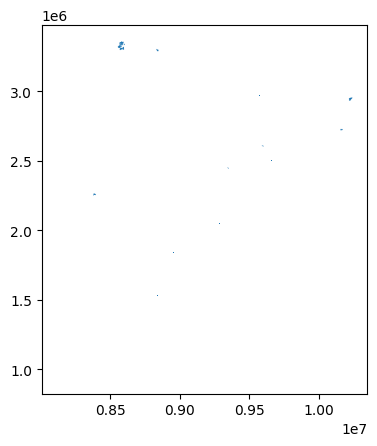

In [42]:
all_leftout_gdf_merge.plot()

In [43]:
all_leftout_gdf_merge = all_leftout_gdf_merge[
    [
        "UID",
        "PCA_ID",
        "State_C",
        "State_N",
        "Dist_C",
        "Dist_N",
        "SubDist_C",
        "SubDist_N",
        "TV_C",
        "TV_N",
        "Ward_C",
        "TOT_P",
        "geometry",
        "state",
        "state_name",
        "district",
        "district_name",
        "subdistrict",
        "subd_name",
        "townvillage",
        "ward_id",
        "wardvillage_name",
        "pca_id",
        "tru",
        "wardvillage_pop",
        "subd_pop",
        "state_pop",
        "wardvillageid",
        "wardboundaryavailablewithmapsolv",
        "sourcesheet",
        "sampledforpanel",
        "sampledforpanelround2",
        "sampledforifs",
        "statesharedbymapsolve",
        "statechanged",
        "wardboundarygiven",
        "tvboundarygiven",
        "subdistrictboundarygiven",
        "deliverystate",
        "psutype",
        "wardcountifs",
        "wardcountpanel",
        "wardcountpanelround2",
        "wardcountall",
        "state_census_id",
        "state_census_name",
        "district_census_id",
        "district_census_name",
        "subdistrict_census_id",
        "subdistrict_census_name",
        "tv_id",
        "tv_name",
        "target_psu",
        "target_psu_type",
        "targets_count",
        "target_pin_type",
        "pin_id",
        "pin_name",
        "gadm_state_name",
        "gadm_district_name",
        "gadm_subdistrict_name",
        "google_maps",
        "latitude",
        "longitude",
        "target_id",
        "my_maps",
        "State",
        "State_Name",
        "District",
        "District_Name",
        "Subdistrict",
        "Subd_Name",
        "TownVillage",
        "WardVillage_Name",
        "TRU",
        "WardVillage_Pop",
        "Subd_Pop",
        "State_Pop",
        "WardVillageID",
        "WardBoundaryAvailablewithMap",
        "_m2",
        "_merge",
        "PSU Type in Rooftop Sample",
        "PSU Type in MapSolve Shapes",
        "urbanwardvillage",
        "UrbanWardVillage",
        "tv_ward_count",
        "tv_sample_count",
        "subdist_ward_count",
        "subdist_sample_count",
        "_m3",
    ]
]

In [44]:
all_leftout_gdf_merge["UID"] = all_leftout_gdf_merge["UID"].astype(float)

In [45]:
save_shapefiles(
    all_leftout_gdf_merge,
    CLEANED_DATA_DIR / "Leftout Shapes",
    "leftout_shapes_after_v4_v6_uttarakhand",
    formats=["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'NCT OF DELHI' of field leftout_shapes_after_v4_v6_uttarakhand.TOT_P parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'DMC (U) (Part) WARD NO.-0059' of field leftout_shapes_after_v4_v6_uttarakhand.townvillage parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '800441-59' of field leftout_shapes_after_v4_v6_uttarakhand.ward_id parsed incompletely to real 800441.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value 'GOOD - Ward boundary given as expected' for boolean field leftout_shapes_after_v4_v6_uttarakhand.tvboundarygiven. Assu

### Learnings and TODO

- The "BAD - Subdistrict boundary given but Ward boundaries expected" was not mapped to PSU Type "subdistrict" (code bug). This means that in this case I don't think the subd boundary was used at all in the sampling stage. Will need to run the matching again (to embed this info which is now part of v7) and run sampling for these missing areas.
- Need to take the IDs of all the missing shapes that are present in MapSolve but not in our sample and find out why they are not appearing in our sample.
